# Sparse PCA RUN2 Experiment: 50% Coordinate Retention and Stronger Penalty

This notebook tests a new Sparse PCA configuration for RUN2. The corrected Sparse PCA pipeline used previously retained the $35\%$ highest-variance velocity coordinates and used $\alpha=1.0$. Here, the retained-coordinate fraction is increased to $50\%$, and the sparsity penalty is increased to $\alpha=2.0$.

The goal is to evaluate whether keeping more spatial coordinates while imposing a stronger penalty produces modes that are still localized but less constrained by the preliminary variance mask. The original compressed PIV file and the previous Sparse PCA cache are read only; the new result is saved to a separate file.

## Mathematical Setup

Let $\mathbf{X}\in\mathbb{R}^{N\times p}$ be the RUN2 fluctuation snapshot matrix, where each row stacks the horizontal and vertical velocity fluctuations,

$$
\mathbf{x}_i = \left(u_i(x_1,y_1),\ldots,u_i(x_m,y_m),v_i(x_1,y_1),\ldots,v_i(x_m,y_m)\right).
$$

Before fitting Sparse PCA, the $50\%$ velocity coordinates with largest temporal standard deviation are retained. This produces a reduced matrix $\mathbf{X}_{\mathcal{S}}$, where $\mathcal{S}$ is the retained feature set. The retained variables are then standardized so that the $\ell_1$ penalty is not dominated only by differences in coordinate scale.

Sparse PCA is fitted with $30$ components and penalty parameter $\alpha=2.0$. In dictionary form, the method seeks an approximate factorization

$$
\mathbf{X}_{\mathcal{S},\mathrm{std}} \approx \mathbf{A}\mathbf{D},
$$

where $\mathbf{A}$ contains the temporal scores and $\mathbf{D}$ contains sparse loading vectors. The learned loadings are then inserted back into the full velocity coordinate space by setting all non-retained coordinates to zero.

In [32]:
from pathlib import Path
from time import perf_counter
import gc
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from numpy.linalg import norm
from sklearn.decomposition import MiniBatchSparsePCA
from sklearn.preprocessing import StandardScaler

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "mathtext.fontset": "stix",
    "font.size": 12,
    "axes.labelsize": 13,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

CURRENT_DIR = Path.cwd()
if CURRENT_DIR.name == "code":
    CODE_DIR = CURRENT_DIR
elif (CURRENT_DIR / "code").exists():
    CODE_DIR = CURRENT_DIR / "code"
else:
    CODE_DIR = Path(r"X:/TFG_datos/code")

COMPRESSED_DATA_PATH = CODE_DIR / "compressed_data" / "RUN2_PIV_compressed.npz"
SPCA_DIR = CODE_DIR / "SPCA_data"
FIGURE_DIR = CODE_DIR / "figures" / "spca_experiments"
SPCA_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_PATH = SPCA_DIR / "RUN2_PIV_SPCA_keep50_alpha2.npz"
METADATA_PATH = SPCA_DIR / "RUN2_PIV_SPCA_keep50_alpha2.json"
BASELINE_PATH = SPCA_DIR / "RUN2_PIV_SPCA.npz"

RUN_ID = 2
N_COMPONENTS = 50
KEEP_Q = 0.50
ALPHA = 0.2
RIDGE_ALPHA = 1e-6
MAX_ITER = 400
RANDOM_STATE = 0
FORCE_REFIT = False

print(f"Code directory: {CODE_DIR}")
print(f"New SPCA output: {OUTPUT_PATH}")

Code directory: x:\TFG_datos\code
New SPCA output: x:\TFG_datos\code\SPCA_data\RUN2_PIV_SPCA_keep50_alpha2.npz


In [33]:
def load_run2_snapshot_matrix(path: Path):
    """Load RUN2 fluctuating velocity fields as a snapshot-feature matrix.

    The compressed dataset is read without modification. The returned matrix has
    shape (n_snapshots, 2 * n_grid), with all u coordinates followed by all v
    coordinates, matching the convention used elsewhere in the project.
    """
    with np.load(path) as data:
        X_grid = data["X"]
        Y_grid = data["Y"]
        n_snapshots, n_y, n_x = data["u"].shape
        n_grid = n_y * n_x

        # Allocate the final matrix once and cast to float32 to reduce memory.
        X_snap = np.empty((n_snapshots, 2 * n_grid), dtype=np.float32)

        # Fill the horizontal and vertical components separately. This avoids
        # keeping unnecessary intermediate concatenations in memory.
        X_snap[:, :n_grid] = data["u"].reshape(n_snapshots, n_grid).astype(np.float32, copy=False)
        X_snap[:, n_grid:] = data["v"].reshape(n_snapshots, n_grid).astype(np.float32, copy=False)

    return X_snap, X_grid, Y_grid


def quantile_mask_by_feature_std(X, keep_q: float):
    """Return a mask selecting the highest-variance feature coordinates."""
    feature_std = X.std(axis=0, ddof=1)
    threshold = np.quantile(feature_std, 1.0 - keep_q)
    return feature_std >= threshold


def sparsity_on_modes(components_full, rel_thr: float = 1e-3):
    """Compute near-zero sparsity over all mode-coordinate loading entries."""
    max_per_mode = np.maximum(np.abs(components_full).max(axis=1, keepdims=True), 1e-12)
    near_zero = np.abs(components_full) < rel_thr * max_per_mode
    return float(near_zero.mean())


def fve_chunked(X_std_masked, scores, components_masked, batch: int = 512):
    """Compute reconstruction FVE in the retained standardized feature space."""
    denom = norm(X_std_masked, "fro") ** 2
    err2 = 0.0
    n = X_std_masked.shape[0]

    for i0 in range(0, n, batch):
        i1 = min(i0 + batch, n)
        reconstruction = scores[i0:i1] @ components_masked
        residual = X_std_masked[i0:i1] - reconstruction
        err2 += norm(residual, "fro") ** 2

    return float(max(0.0, 1.0 - err2 / max(denom, 1e-12)))


def fit_sparse_pca_experiment(
    X_snap,
    n_components: int,
    keep_q: float,
    alpha: float,
    ridge_alpha: float,
    max_iter: int,
    random_state: int,
):
    """Fit the corrected Sparse PCA pipeline for one parameter setting."""
    t0 = perf_counter()
    n_samples, n_features = X_snap.shape

    # First, retain the most active velocity coordinates by temporal variance.
    feature_mask = quantile_mask_by_feature_std(X_snap, keep_q=keep_q)
    X_masked = X_snap[:, feature_mask]

    # Standardization makes the L1 penalty act on comparable feature scales.
    #scaler = StandardScaler(with_mean=True, with_std=True)
    #X_std_masked = scaler.fit_transform(X_masked).astype(np.float32, copy=False)
    X_std_masked = X_masked
    # MiniBatchSparsePCA keeps the fit tractable for the large PIV matrix.
    batch_size = min(2048, max(128, n_samples // 20))
    model = MiniBatchSparsePCA(
        n_components=n_components,
        alpha=alpha,
        ridge_alpha=ridge_alpha,
        batch_size=batch_size,
        n_jobs=-1,
        max_iter=max_iter,
        random_state=random_state,
    )
    model.fit(X_std_masked)

    components_masked = model.components_.astype(np.float32, copy=False)
    scores = model.transform(X_std_masked).astype(np.float32, copy=False)

    # Put the sparse modes back in the original full coordinate space.
    components_full = np.zeros((n_components, n_features), dtype=np.float32)
    components_full[:, feature_mask] = components_masked

    fve = fve_chunked(X_std_masked, scores, components_masked)
    sparsity = sparsity_on_modes(components_full)

    return {
        "components": components_full,
        "scores": scores,
        "feature_mask": feature_mask,
        "sparsity_modes": sparsity,
        "FVE": fve,
        "time_sec": float(perf_counter() - t0),
        "kept_features": int(feature_mask.sum()),
        "total_features": int(n_features),
        "batch_size": int(batch_size),
    }

In [34]:
if OUTPUT_PATH.exists() and not FORCE_REFIT:
    print(f"Loading existing result from {OUTPUT_PATH}")
    with np.load(OUTPUT_PATH) as data:
        result = {
            "components": data["components"],
            "scores": data["scores"],
            "feature_mask": data["feature_mask"],
            "sparsity_modes": float(data["sparsity_modes"]),
            "FVE": float(data["FVE"]),
            "time_sec": float(data["time_sec"]),
            "kept_features": int(data["feature_mask"].sum()),
            "total_features": int(data["feature_mask"].size),
            "batch_size": int(data["batch_size"]) if "batch_size" in data.files else None,
        }
    with np.load(COMPRESSED_DATA_PATH) as data:
        X_grid = data["X"]
        Y_grid = data["Y"]
else:
    print("Loading RUN2 compressed fluctuations...")
    X_snap, X_grid, Y_grid = load_run2_snapshot_matrix(COMPRESSED_DATA_PATH)
    print(f"Snapshot matrix shape: {X_snap.shape}")

    print(f"Fitting Sparse PCA with keep_q={KEEP_Q:.2f}, alpha={ALPHA:.2f}, n_components={N_COMPONENTS}...")
    result = fit_sparse_pca_experiment(
        X_snap,
        n_components=N_COMPONENTS,
        keep_q=KEEP_Q,
        alpha=ALPHA,
        ridge_alpha=RIDGE_ALPHA,
        max_iter=MAX_ITER,
        random_state=RANDOM_STATE,
    )

    np.savez(
        OUTPUT_PATH,
        components=result["components"],
        scores=result["scores"],
        feature_mask=result["feature_mask"],
        sparsity_modes=result["sparsity_modes"],
        FVE=result["FVE"],
        time_sec=result["time_sec"],
        keep_q=KEEP_Q,
        alpha=ALPHA,
        n_components=N_COMPONENTS,
        ridge_alpha=RIDGE_ALPHA,
        max_iter=MAX_ITER,
        random_state=RANDOM_STATE,
        batch_size=result["batch_size"],
    )

    metadata = {
        "run_id": RUN_ID,
        "input_file": str(COMPRESSED_DATA_PATH),
        "output_file": str(OUTPUT_PATH),
        "n_components": N_COMPONENTS,
        "keep_q": KEEP_Q,
        "alpha": ALPHA,
        "ridge_alpha": RIDGE_ALPHA,
        "max_iter": MAX_ITER,
        "random_state": RANDOM_STATE,
        "kept_features": result["kept_features"],
        "total_features": result["total_features"],
        "sparsity_modes": result["sparsity_modes"],
        "FVE": result["FVE"],
        "time_sec": result["time_sec"],
    }
    METADATA_PATH.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

    # Release the full snapshot matrix before plotting or comparing summaries.
    del X_snap
    gc.collect()

print(f"Kept features: {result['kept_features']} / {result['total_features']} ({100 * result['kept_features'] / result['total_features']:.1f}%)")
print(f"Zero or near-zero loading entries: {100 * result['sparsity_modes']:.2f}%")
print(f"Reconstruction FVE on retained standardized coordinates: {result['FVE']:.4f}")
print(f"Computation time: {result['time_sec']:.1f} s")
print(f"Saved result: {OUTPUT_PATH}")

Loading RUN2 compressed fluctuations...
Snapshot matrix shape: (2030, 171622)
Fitting Sparse PCA with keep_q=0.50, alpha=0.20, n_components=50...
Kept features: 85811 / 171622 (50.0%)
Zero or near-zero loading entries: 92.02%
Reconstruction FVE on retained standardized coordinates: 0.9339
Computation time: 29.9 s
Saved result: x:\TFG_datos\code\SPCA_data\RUN2_PIV_SPCA_keep50_alpha2.npz


## Diagnostic Comparison with the Previous Sparse PCA Run

The previous corrected Sparse PCA run retained $35\%$ of the coordinates and used $\alpha=1.0$. The table below compares the previous result with the new configuration. The FVE values are reconstruction diagnostics in each retained standardized coordinate space, so they should be compared cautiously because the retained feature sets are not identical.

In [35]:
def load_spca_summary(path: Path, label: str, keep_q: float | None, alpha: float | None):
    """Load scalar diagnostics from a stored Sparse PCA result."""
    with np.load(path) as data:
        feature_mask = data["feature_mask"]
        return {
            "configuration": label,
            "keep_q": keep_q if keep_q is not None else float(data["keep_q"]) if "keep_q" in data.files else np.nan,
            "alpha": alpha if alpha is not None else float(data["alpha"]) if "alpha" in data.files else np.nan,
            "n_components": int(data["n_components"]) if "n_components" in data.files else data["components"].shape[0],
            "kept_features": int(feature_mask.sum()),
            "total_features": int(feature_mask.size),
            "kept_pct": 100 * int(feature_mask.sum()) / int(feature_mask.size),
            "sparsity_pct": 100 * float(data["sparsity_modes"]),
            "FVE": float(data["FVE"]),
            "time_sec": float(data["time_sec"]),
        }

summary_df = pd.DataFrame([
    load_spca_summary(BASELINE_PATH, "baseline keep35 alpha1", keep_q=0.35, alpha=1.0),
    load_spca_summary(OUTPUT_PATH, "new keep50 alpha2", keep_q=KEEP_Q, alpha=ALPHA),
])

summary_df[[
    "configuration", "keep_q", "alpha", "n_components", "kept_features",
    "kept_pct", "sparsity_pct", "FVE", "time_sec"
]].round({"kept_pct": 2, "sparsity_pct": 2, "FVE": 4, "time_sec": 1})

,configuration,keep_q,alpha,n_components,kept_features,kept_pct,sparsity_pct,FVE,time_sec
0,baseline keep35 alpha1,0.35,1.0,30,60068,35.0,80.67,0.8042,83.3
1,new keep50 alpha2,0.50,0.2,50,85811,50.0,92.02,0.9339,29.9


## Spatial Mode Visualization

The first six sparse components are plotted below after ordering them by the variance of their temporal scores. This ordering is used only as a diagnostic, because Sparse PCA does not provide the same variance-optimal sequence of modes as PCA/POD.

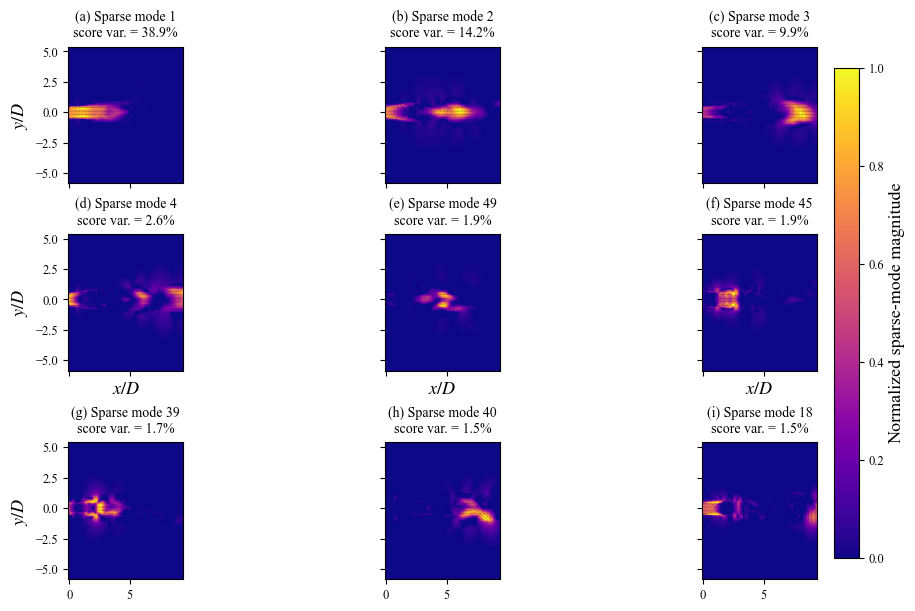

Panel 1: sparse mode 1, score-variance share = 38.93%
Panel 2: sparse mode 2, score-variance share = 14.19%
Panel 3: sparse mode 3, score-variance share = 9.94%
Panel 4: sparse mode 4, score-variance share = 2.59%
Panel 5: sparse mode 49, score-variance share = 1.89%
Panel 6: sparse mode 45, score-variance share = 1.85%
Panel 7: sparse mode 39, score-variance share = 1.70%
Panel 8: sparse mode 40, score-variance share = 1.54%
Panel 9: sparse mode 18, score-variance share = 1.52%
First six displayed modes: cumulative score-variance share = 74.15%
Saved PNG: x:\TFG_datos\code\figures\spca_experiments\run2_spca_keep50_alpha2_modes.png
Saved PDF: x:\TFG_datos\code\figures\spca_experiments\run2_spca_keep50_alpha2_modes.pdf


In [39]:
def reshape_sparse_modes(components, X_grid):
    """Split full sparse components into u and v loading fields."""
    n_grid = X_grid.size
    modes = []
    for component in components:
        u_mode = component[:n_grid].reshape(X_grid.shape)
        v_mode = component[n_grid:2 * n_grid].reshape(X_grid.shape)
        modes.append((u_mode, v_mode))
    return modes


def plot_sparse_modes(result, X_grid, Y_grid, output_stem: str, n_modes: int = 6):
    """Plot the leading sparse modes ordered by temporal score variance."""
    components = result["components"]
    scores = result["scores"]
    modes = reshape_sparse_modes(components, X_grid)

    score_variance = np.var(scores, axis=0, ddof=1)
    score_share = score_variance / np.sum(score_variance)
    mode_order = np.argsort(score_share)[::-1][:n_modes]

    fig, axes = plt.subplots(3, 3, figsize=(10.4, 6.0), sharex=True, sharey=True, constrained_layout=True)
    axes_flat = axes.ravel()

    mesh = None
    for panel_idx, (ax, mode_idx) in enumerate(zip(axes_flat, mode_order), start=1):
        u_mode, v_mode = modes[mode_idx]
        magnitude = np.sqrt(u_mode**2 + v_mode**2)
        magnitude_max = float(np.nanmax(magnitude))
        magnitude_plot = magnitude / magnitude_max if magnitude_max > 0 else magnitude

        mesh = ax.pcolormesh(
            X_grid,
            Y_grid,
            magnitude_plot,
            cmap="plasma",
            shading="auto",
            vmin=0.0,
            vmax=1.0,
            rasterized=True,
        )

        # Normalize arrows for readability within each panel.
        u_plot = u_mode / magnitude_max if magnitude_max > 0 else u_mode
        v_plot = v_mode / magnitude_max if magnitude_max > 0 else v_mode
        step = 8
        ax.quiver(
            X_grid[::step, ::step],
            Y_grid[::step, ::step],
            u_plot[::step, ::step],
            v_plot[::step, ::step],
            color="k",
            alpha=0.55,
            scale=18.0,
            width=0.0022,
            headwidth=3.0,
        )

        panel_label = chr(96 + panel_idx)
        ax.set_title(
            f"({panel_label}) Sparse mode {mode_idx + 1}\nscore var. = {100 * score_share[mode_idx]:.1f}%",
            fontsize=10,
            pad=7,
        )
        ax.set_aspect("equal")
        ax.tick_params(labelsize=9)

    for row in range(3):
        axes[row, 0].set_ylabel(r"$y/D$")
    for col in range(3):
        axes[1, col].set_xlabel(r"$x/D$")

    cbar = fig.colorbar(mesh, ax=axes_flat.tolist(), fraction=0.026, pad=0.018)
    cbar.set_label("Normalized sparse-mode magnitude")
    cbar.ax.tick_params(labelsize=9)

    png_path = FIGURE_DIR / f"{output_stem}.png"
    pdf_path = FIGURE_DIR / f"{output_stem}.pdf"
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")
    plt.show()

    return mode_order, score_share[mode_order], png_path, pdf_path

mode_order, score_shares, png_path, pdf_path = plot_sparse_modes(
    result,
    X_grid,
    Y_grid,
    output_stem="run2_spca_keep50_alpha2_modes",
    n_modes=9,
)

for panel_idx, (mode_idx, share) in enumerate(zip(mode_order, score_shares), start=1):
    print(f"Panel {panel_idx}: sparse mode {mode_idx + 1}, score-variance share = {100 * share:.2f}%")
print(f"First six displayed modes: cumulative score-variance share = {100 * np.sum(score_shares):.2f}%")
print(f"Saved PNG: {png_path}")
print(f"Saved PDF: {pdf_path}")

## Interpretation

The new configuration retained $85\,811$ of the $171\,622$ velocity coordinates, exactly $50.0\%$ of the full velocity space. Despite retaining more coordinates than the previous corrected Sparse PCA run, the stronger penalty $\alpha=2.0$ produced a higher fraction of zero or near-zero loading entries: $84.97\%$, compared with $80.67\%$ in the baseline configuration. This shows that the final sparsity is not determined only by the preliminary feature mask; the $\ell_1$ penalty still removes many entries inside the retained coordinate set.

The reconstruction FVE in the retained standardized coordinate space increased from $0.8042$ to $0.8190$. This improvement should be interpreted cautiously because the retained feature set changed from $35\%$ to $50\%$ of the coordinates. The two FVE values are therefore diagnostics of two different standardized spaces, not directly comparable physical-energy fractions. Still, the result indicates that the new setting keeps enough additional spatial information to improve the internal reconstruction metric while remaining highly sparse.

The spatial modes are more fragmented than in the previous Sparse PCA figure. The two largest components still describe broad structures around the jet core and shear-layer envelope, but the remaining high-score-variance components are more localized and appear in separated regions of the field. The fact that modes $24$ and $19$ appear among the six largest score-variance components also confirms that the fitted Sparse PCA components are not naturally ordered by importance and must be ranked after fitting. Overall, this experiment suggests that increasing the retained coordinate fraction while increasing $\alpha$ produces a more selective decomposition: the model has access to more spatial coordinates, but the stronger penalty forces it to use them in a more localized way.